# Generate Deletion Figure

EDA

In [33]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [34]:
method1 = "attention_mask"
path = Path(f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/deletion/deletion_curves/attention_rollout/{method1}/" \
f"02F4A1FB_left_curve_{method1}.npy")
data = np.load(path, allow_pickle=True).item()
print("columns in npy files"+str(list(data.keys())))
print("----")
print("label is " + str(data["predicted_class"]))
print("All confidences from deletion on each step"+str(data['predicted_confidences']))
#print("Confidences on class 2" + str(data['confidences'][:, -1:]))


columns in npy files['percentages', 'confidences', 'normalized_confidences', 'predicted_class', 'predicted_confidences', 'predicted_normalized_confidences', 'auc', 'baseline']
----
label is 2
All confidences from deletion on each step[0.5886417 0.5886417 0.5886417 0.5886417 0.5886417 0.5886417 0.5886417
 0.5886417 0.5886417 0.5886417 0.5886417 0.5886417 0.5886417 0.5886417
 0.5886417 0.5886417 0.5886417 0.5886417 0.5886417 0.5886417 0.5886417]


In [36]:
method = "mean"

#I would like to compare confidences on the same image in different evluation only on the percentages = 0
compare_path = Path(f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/deletion/deletion_curves/attention_rollout/{method}/" \
f"02F4A1FB_left_curve_{method}.npy")
compare_data = np.load(compare_path, allow_pickle=True).item()


print(f"Method is {method}")
print("label is " + str(compare_data["predicted_class"]))
print("All confidences from deletion on each step "+str(compare_data['predicted_confidences'][0]))
print("Confidences on class 2 at 0% is " + str(compare_data['confidences'][0, 2]))

print("----")
print("Attention Mask")
print("All confidences from deletion on each step "+str(data['predicted_confidences'][0]))
print("Confidences on class 2 at 0% is " + str(data['confidences'][0, 2]))


Method is mean
label is 2
All confidences from deletion on each step 0.5886417
Confidences on class 2 at 0% is 0.5886417
----
Attention Mask
All confidences from deletion on each step 0.5886417
Confidences on class 2 at 0% is 0.5886417


it should be same why it's different

## Attention

### Overall

curves shape: (116, 21)
percentages shape: (21,)


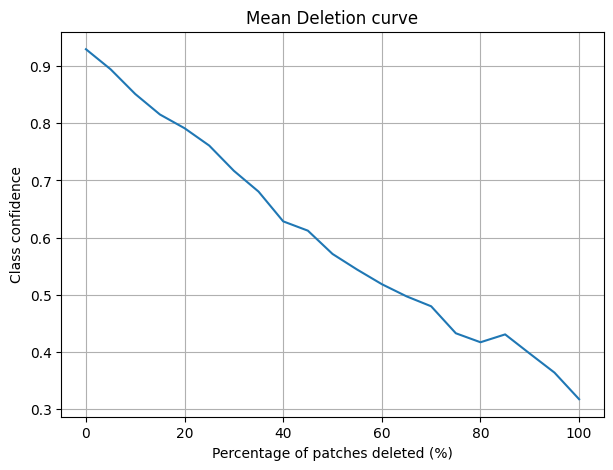

-----------------------
-----------------------
-----------------------


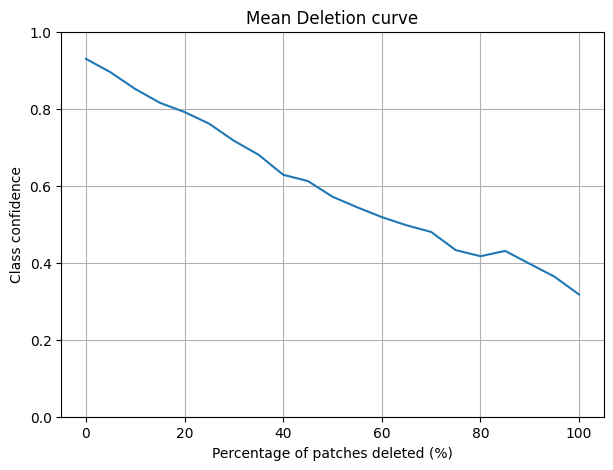

In [ ]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention") 
curves = []
percentages = None

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    curves.append(data["predicted_confidences"])
    if percentages is None:
        percentages = data["percentages"]

curves = np.array(curves)
mean_conf = curves.mean(axis=0)

print("curves shape:", curves.shape)
print("percentages shape:", np.array(percentages).shape)


x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()


print ("-----------------------")
print ("-----------------------")
print ("-----------------------")


plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylim(0, 1)
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()




### Each Class

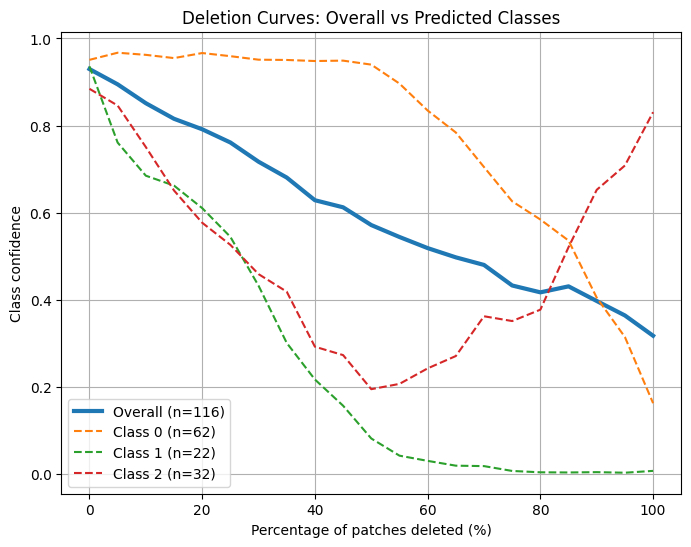

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention")
csv_path = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_attention.csv")

# Load CSV
df = pd.read_csv(csv_path)
uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

all_curves = []
class_curves = {}
percentages = None

# Load curves
for f in curve_dir.glob("*.npy"):
    uid = f.stem.replace("_curve", "")
    
    if uid not in uid_to_class:
        continue

    data = np.load(f, allow_pickle=True).item()
    confidences = data["predicted_confidences"]
    
    all_curves.append(confidences)
    
    cls = uid_to_class[uid]
    if cls not in class_curves:
        class_curves[cls] = []
    class_curves[cls].append(confidences)
    
    if percentages is None:
        percentages = data["percentages"]

# Safety check
if len(all_curves) == 0:
    raise ValueError("No matching curves found.")

# Convert to numpy
all_curves = np.array(all_curves)
overall_mean = all_curves.mean(axis=0)

# Plot
x_percent = np.array(percentages) * 100
plt.figure(figsize=(8, 6))

# Overall curve (thicker line)
plt.plot(
    x_percent,
    overall_mean,
    linewidth=3,
    label=f"Overall (n={len(all_curves)})"
)

# Per-class curves
for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linestyle="--",
        label=f"Class {cls} (n={len(curves)})"
    )

plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title("Deletion Curves: Overall vs Predicted Classes")
plt.legend()
plt.grid(True)
plt.show()


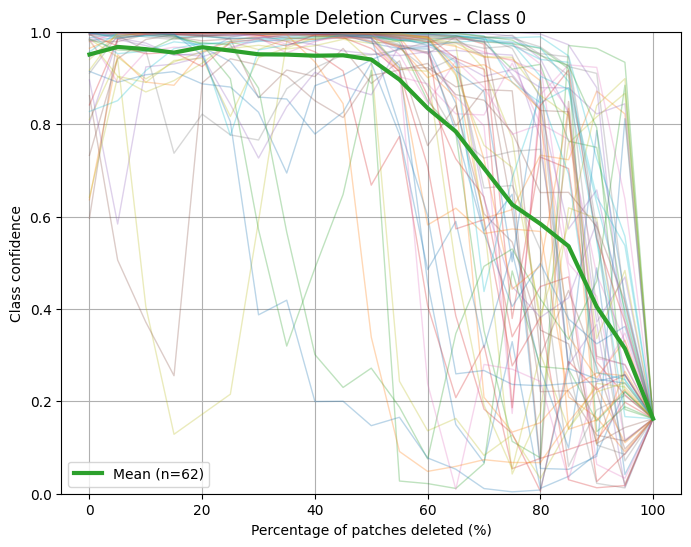

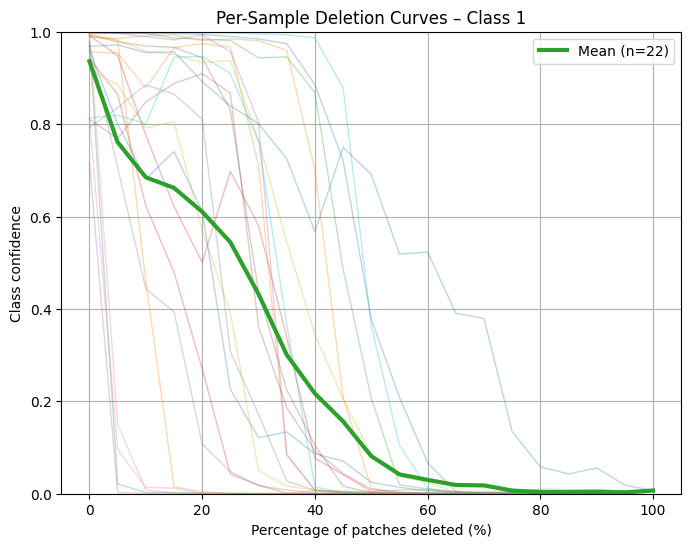

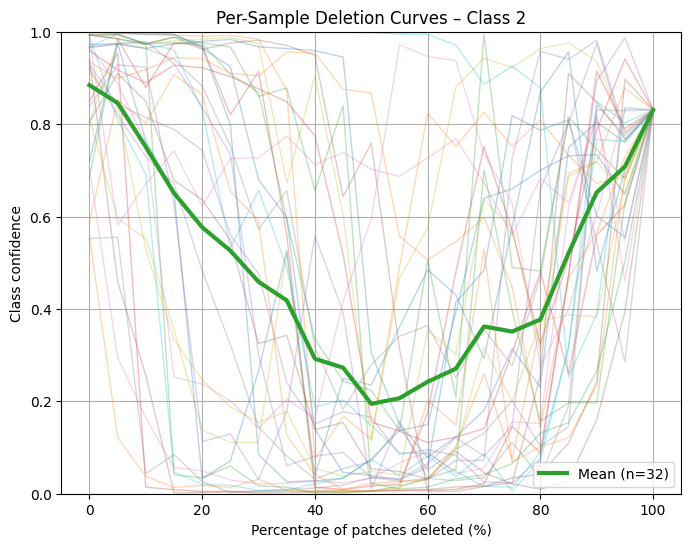

In [ ]:
# --- Plot per-sample curves for every class ---

x_percent = np.array(percentages) * 100

for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)

    plt.figure(figsize=(8, 6))

    # Plot individual sample curves (light lines)
    for curve in curves:
        plt.plot(
            x_percent,
            curve,
            alpha=0.3,
            linewidth=1
        )

    # Plot mean curve (bold)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linewidth=3,
        label=f"Mean (n={len(curves)})"
    )

    plt.xlabel("Percentage of patches deleted (%)")
    plt.ylabel("Class confidence")
    plt.title(f"Per-Sample Deletion Curves – Class {cls}")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()


## Attention Rollout

#### Overall

curves shape: (116, 21)
percentages shape: (21,)


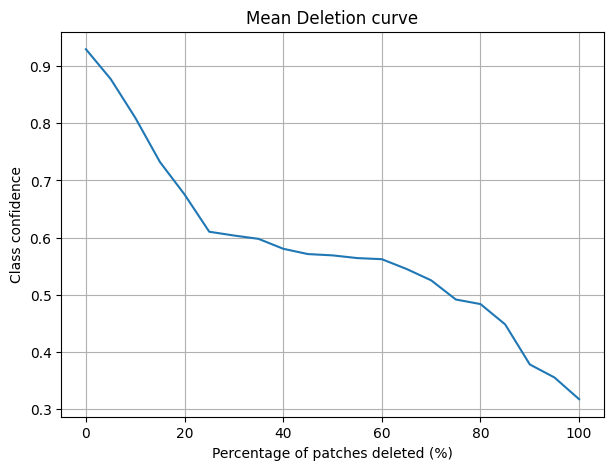

-----------------------
-----------------------
-----------------------


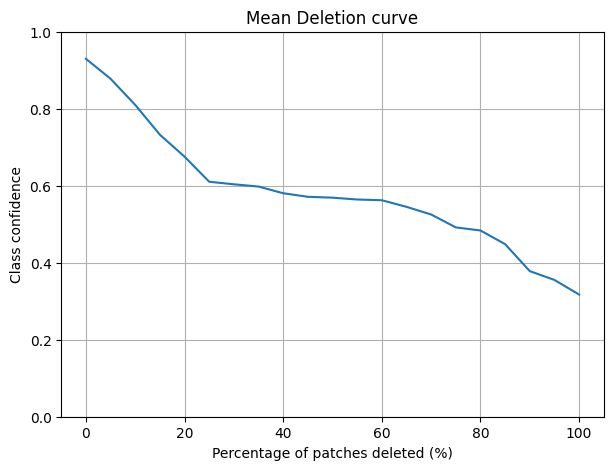

In [ ]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention_rollout") 
curves = []
percentages = None

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    curves.append(data["confidences"])
    if percentages is None:
        percentages = data["percentages"]

curves = np.array(curves)
mean_conf = curves.mean(axis=0)

print("curves shape:", curves.shape)
print("percentages shape:", np.array(percentages).shape)


x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()


print ("-----------------------")
print ("-----------------------")
print ("-----------------------")


plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylim(0, 1)
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()




#### Each Class

#### Overall - "BLACK"

In [ ]:
path = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention_rollout/black/02F4A1FB_left_curve_black.npy")
data = np.load(path, allow_pickle=True).item()
list(data.keys())


['percentages',
 'confidences',
 'normalized_confidences',
 'predicted_class',
 'predicted_confidences',
 'predicted_normalized_confidences',
 'auc',
 'baseline']

In [ ]:
print(data['predicted_confidences'])
print(data['confidences'][:, -1:])

[0.5886417  0.3623032  0.2620221  0.03905889 0.03831822 0.03587325
 0.0489917  0.04567838 0.02285638 0.02285521 0.01819856 0.02755756
 0.06733793 0.058701   0.07117386 0.01518851 0.06946148 0.306531
 0.55028975 0.7340041  0.8305886 ]
[[0.5886417 ]
 [0.3623032 ]
 [0.2620221 ]
 [0.03905889]
 [0.03831822]
 [0.03587325]
 [0.0489917 ]
 [0.04567838]
 [0.02285638]
 [0.02285521]
 [0.01819856]
 [0.02755756]
 [0.06733793]
 [0.058701  ]
 [0.07117386]
 [0.01518851]
 [0.06946148]
 [0.306531  ]
 [0.55028975]
 [0.7340041 ]
 [0.8305886 ]]


curves shape: (116, 21)
percentages shape: (21,)


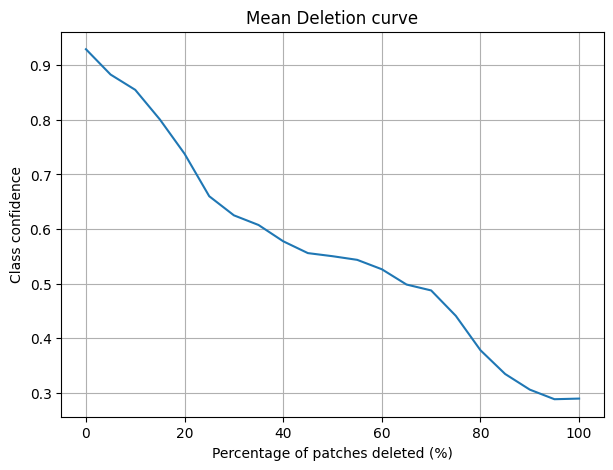

-----------------------
-----------------------
-----------------------


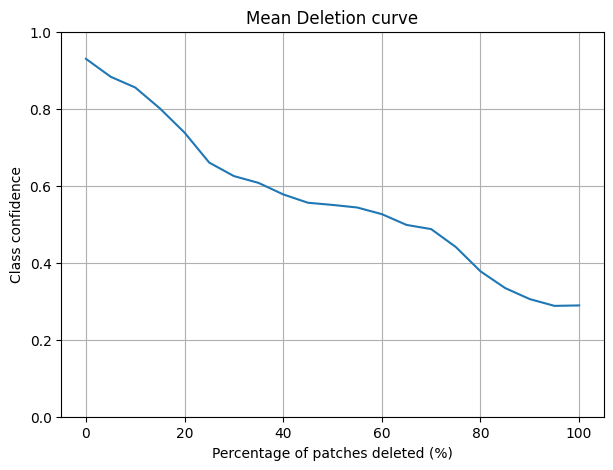

In [ ]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention_rollout/black") 
curves = []
percentages = None

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    curves.append(data["predicted_confidences"])
    if percentages is None:
        percentages = data["percentages"]

curves = np.array(curves)
mean_conf = curves.mean(axis=0)

print("curves shape:", curves.shape)
print("percentages shape:", np.array(percentages).shape)


x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()


print ("-----------------------")
print ("-----------------------")
print ("-----------------------")


plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylim(0, 1)
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()




#### Each Class

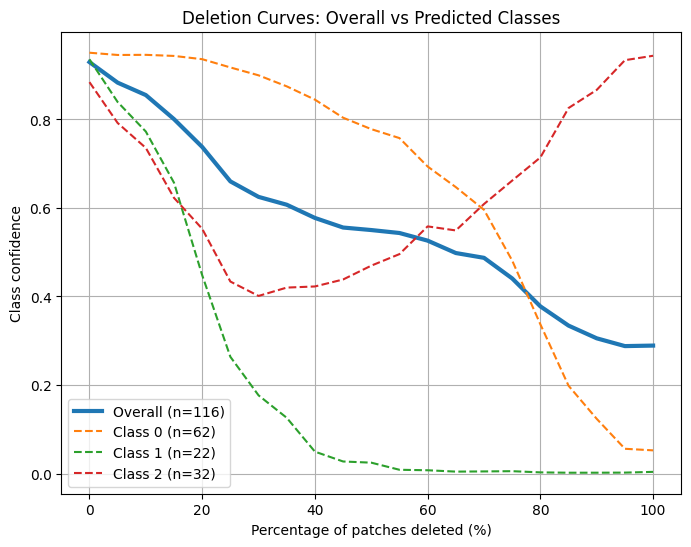

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention_rollout/black")
csv_path = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_attention_rollout_black.csv")

# Load CSV
df = pd.read_csv(csv_path)
uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

all_curves = []
class_curves = {}
percentages = None

# Load curves
for f in curve_dir.glob("*.npy"):
    uid = f.stem.replace("_curve_black", "")
    
    if uid not in uid_to_class:
        continue

    data = np.load(f, allow_pickle=True).item()
    confidences = data["predicted_confidences"]
    
    all_curves.append(confidences)
    
    cls = uid_to_class[uid]
    if cls not in class_curves:
        class_curves[cls] = []
    class_curves[cls].append(confidences)
    
    if percentages is None:
        percentages = data["percentages"]

# Safety check
if len(all_curves) == 0:
    raise ValueError("No matching curves found.")

# Convert to numpy
all_curves = np.array(all_curves)
overall_mean = all_curves.mean(axis=0)

# Plot
x_percent = np.array(percentages) * 100
plt.figure(figsize=(8, 6))

# Overall curve (thicker line)
plt.plot(
    x_percent,
    overall_mean,
    linewidth=3,
    label=f"Overall (n={len(all_curves)})"
)

# Per-class curves
for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linestyle="--",
        label=f"Class {cls} (n={len(curves)})"
    )

plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title("Deletion Curves: Overall vs Predicted Classes")
plt.legend()
plt.grid(True)
plt.show()


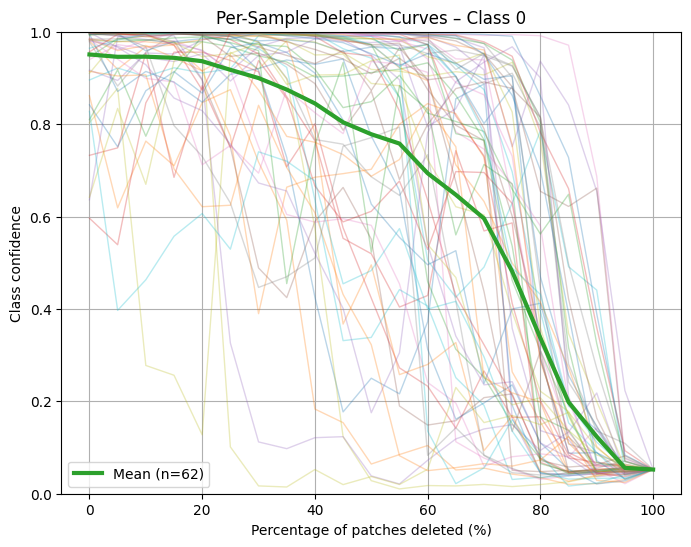

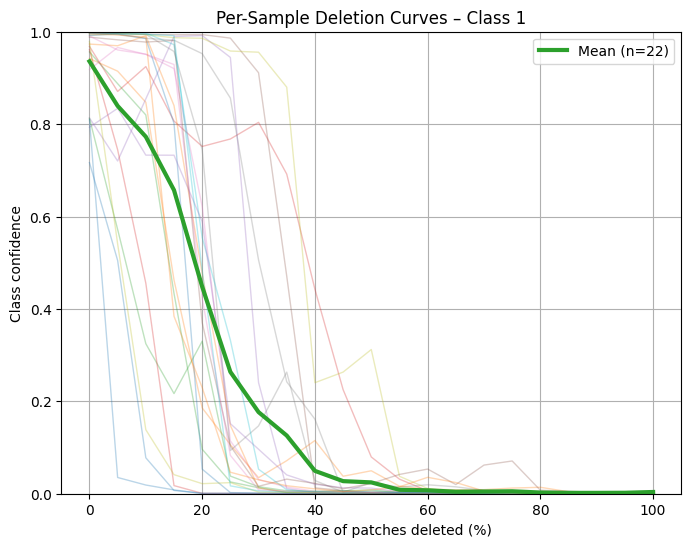

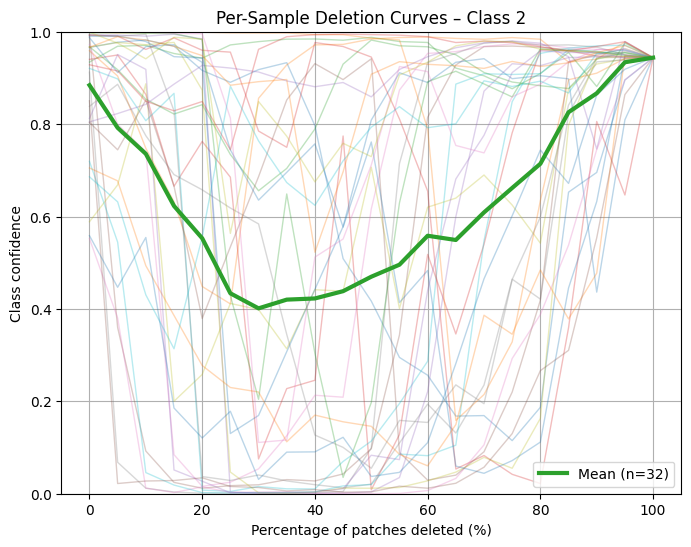

In [ ]:
# --- Plot per-sample curves for every class ---

x_percent = np.array(percentages) * 100

for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)

    plt.figure(figsize=(8, 6))

    # Plot individual sample curves (light lines)
    for curve in curves:
        plt.plot(
            x_percent,
            curve,
            alpha=0.3,
            linewidth=1
        )

    # Plot mean curve (bold)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linewidth=3,
        label=f"Mean (n={len(curves)})"
    )

    plt.xlabel("Percentage of patches deleted (%)")
    plt.ylabel("Class confidence")
    plt.title(f"Per-Sample Deletion Curves – Class {cls}")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()


#### Mean Calculate Exclude Class 0

#### Overall - "BLACK-10"

In [ ]:
path = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention_rollout/black-10/02F4A1FB_left_curve_black-10.npy")
data = np.load(path, allow_pickle=True).item()
list(data.keys())


['percentages',
 'confidences',
 'normalized_confidences',
 'predicted_class',
 'predicted_confidences',
 'predicted_normalized_confidences',
 'auc',
 'baseline']

In [ ]:
print(data['predicted_confidences'])
print(data['confidences'][:, -1:])

[0.5886417  0.63139194 0.67626965 0.6119058  0.6128641  0.6804478
 0.69337064 0.6602078  0.7023714  0.7271121  0.81714964 0.8153966
 0.8209574  0.3047334  0.26936623 0.28563857 0.26882854 0.25286812
 0.23378092 0.23522665 0.21017341 0.20742798 0.27104264 0.3580947
 0.3904811  0.3854391  0.37580356 0.36839056 0.38737935 0.3305865
 0.3167898  0.3639484  0.28542045 0.23630112 0.24170135 0.22856306
 0.23940168 0.20654109 0.15938908 0.18996708 0.15335466 0.14660704
 0.13817908 0.14386104 0.13069774 0.11523679 0.12750807 0.14851114
 0.1270021  0.12157955 0.09956774 0.0986048  0.11552177 0.11166251
 0.10101638 0.11152605 0.11164306 0.12567413 0.12403218 0.13042279
 0.11852174 0.12231343 0.12648022 0.13206422 0.13400793 0.12899426
 0.15686473 0.15939602 0.16138531 0.16984923 0.1854149  0.14624044
 0.17204751 0.182822   0.2019489  0.18366843 0.20065308 0.23909473
 0.2855092  0.2988806  0.29899096 0.4775016  0.44219124 0.49352902
 0.6149253  0.7290593  0.78418744 0.81859666 0.81484115 0.8533933


In [ ]:
print(data['predicted_class'])
print(data['predicted_normalized_confidences'])
print(data['normalized_confidences'][:, -1:])

2
[0.63716954 0.69275546 0.7511076  0.66741866 0.66866463 0.75654024
 0.7733431  0.7302232  0.78504634 0.8172154  0.93428653 0.93200713
 0.9392376  0.2680183  0.22203222 0.24319029 0.22133309 0.20058057
 0.17576249 0.17764229 0.14506687 0.14149712 0.22421198 0.3374012
 0.3795116  0.37295574 0.36042714 0.3507884  0.37547854 0.30163375
 0.28369462 0.3450125  0.24290667 0.17903937 0.18606101 0.16897796
 0.18307087 0.14034395 0.07903464 0.11879363 0.0711884  0.06241482
 0.05145638 0.05884434 0.04172879 0.02162571 0.03758143 0.06489062
 0.03692354 0.02987288 0.00125206 0.         0.02199625 0.01697826
 0.00313565 0.01680083 0.01695297 0.03519684 0.03306191 0.04137127
 0.02589696 0.03082711 0.03624497 0.04350555 0.04603285 0.03951383
 0.07575236 0.07904367 0.08163024 0.09263543 0.11287466 0.06193815
 0.09549374 0.10950325 0.13437296 0.11060382 0.13268808 0.18267176
 0.24302208 0.26040822 0.26055172 0.4926598  0.4467476  0.51349944
 0.67134476 0.8197472  0.89142746 0.936168   0.9312849  0.981

curves shape: (116, 101)
percentages shape: (101,)


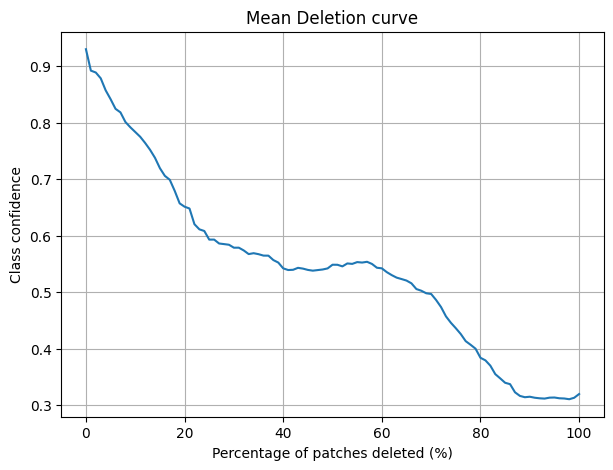

-----------------------
-----------------------
-----------------------


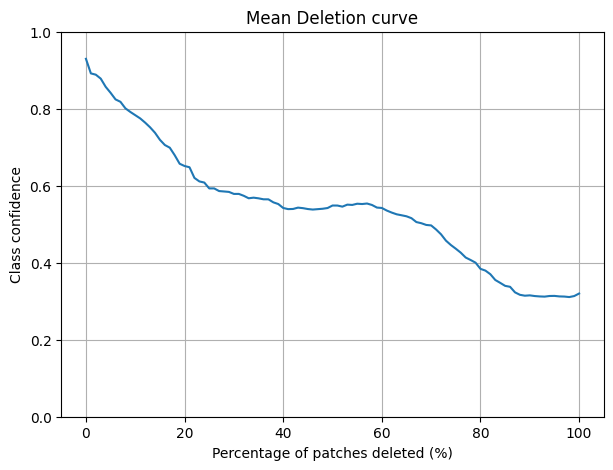

In [ ]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention_rollout/black-10") 
curves = []
percentages = None

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    curves.append(data["predicted_confidences"])
    if percentages is None:
        percentages = data["percentages"]

curves = np.array(curves)
mean_conf = curves.mean(axis=0)

print("curves shape:", curves.shape)
print("percentages shape:", np.array(percentages).shape)


x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()


print ("-----------------------")
print ("-----------------------")
print ("-----------------------")


plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches deleted (%)")
plt.ylim(0, 1)
plt.ylabel("Class confidence")
plt.title("Mean Deletion curve")
plt.grid(True)
plt.show()




#### Each Class

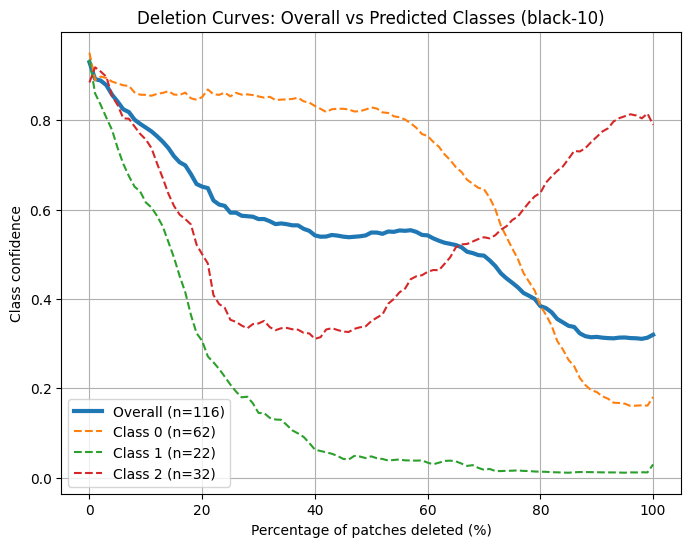

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_curves/attention_rollout/black-10")
csv_path = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/deletion/deletion_attention_rollout_black-10.csv")

# Load CSV
df = pd.read_csv(csv_path)
uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

all_curves = []
class_curves = {}
percentages = None

# Load curves
for f in curve_dir.glob("*.npy"):
    uid = f.stem.replace("_curve_black-10", "")
    
    if uid not in uid_to_class:
        continue

    data = np.load(f, allow_pickle=True).item()
    confidences = data["predicted_confidences"]
    
    all_curves.append(confidences)
    
    cls = uid_to_class[uid]
    if cls not in class_curves:
        class_curves[cls] = []
    class_curves[cls].append(confidences)
    
    if percentages is None:
        percentages = data["percentages"]

# Safety check
if len(all_curves) == 0:
    raise ValueError("No matching curves found.")

# Convert to numpy
all_curves = np.array(all_curves)
overall_mean = all_curves.mean(axis=0)

# Plot
x_percent = np.array(percentages) * 100
plt.figure(figsize=(8, 6))

# Overall curve (thicker line)
plt.plot(
    x_percent,
    overall_mean,
    linewidth=3,
    label=f"Overall (n={len(all_curves)})"
)

# Per-class curves
for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linestyle="--",
        label=f"Class {cls} (n={len(curves)})"
    )

plt.xlabel("Percentage of patches deleted (%)")
plt.ylabel("Class confidence")
plt.title("Deletion Curves: Overall vs Predicted Classes (black-10)")
plt.legend()
plt.grid(True)
plt.show()


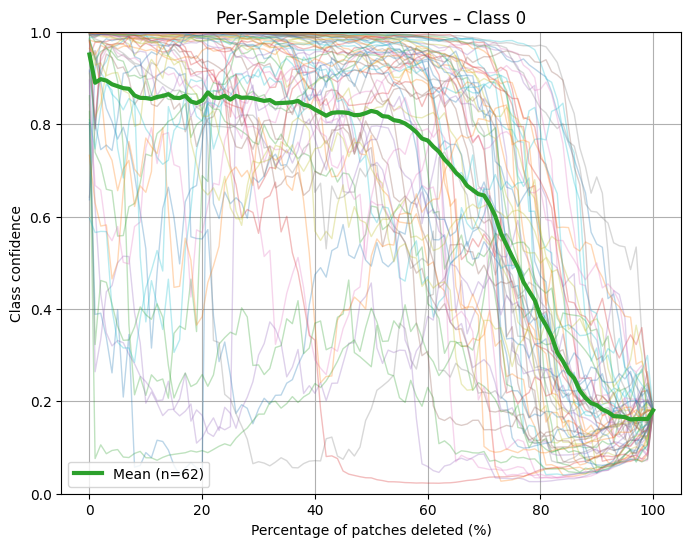

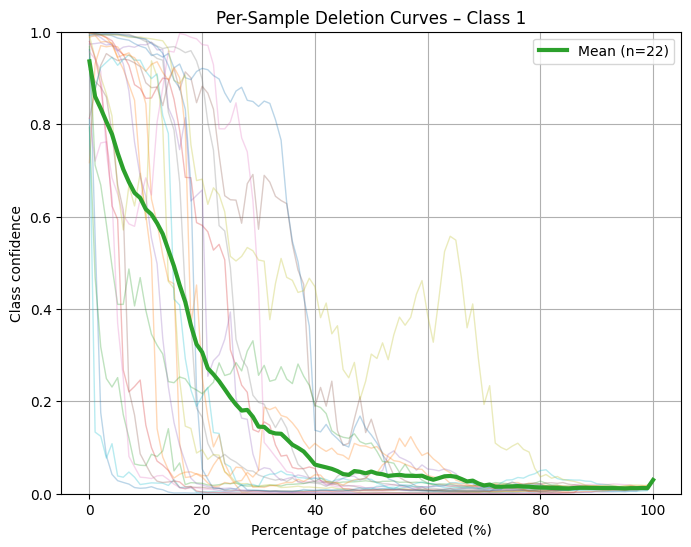

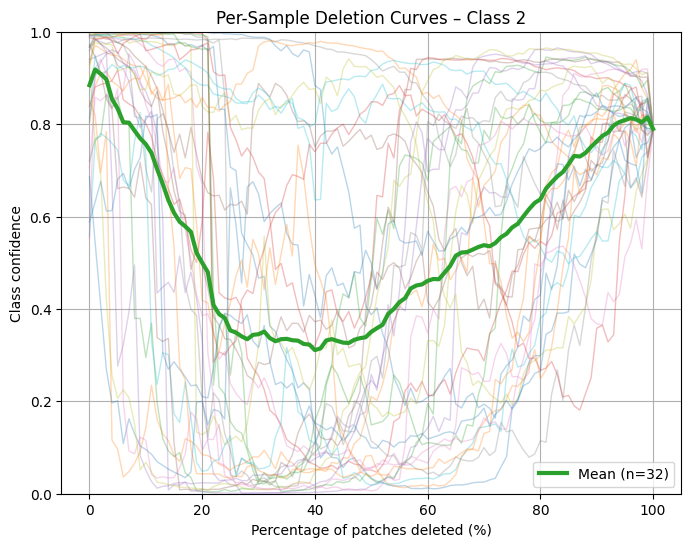

In [ ]:
# --- Plot per-sample curves for every class ---

x_percent = np.array(percentages) * 100

for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)

    plt.figure(figsize=(8, 6))

    # Plot individual sample curves (light lines)
    for curve in curves:
        plt.plot(
            x_percent,
            curve,
            alpha=0.3,
            linewidth=1
        )

    # Plot mean curve (bold)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linewidth=3,
        label=f"Mean (n={len(curves)})"
    )

    plt.xlabel("Percentage of patches deleted (%)")
    plt.ylabel("Class confidence")
    plt.title(f"Per-Sample Deletion Curves – Class {cls}")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()


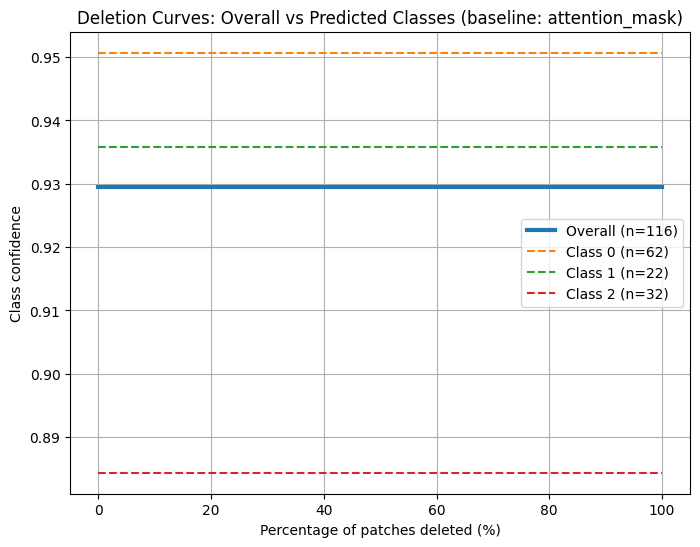

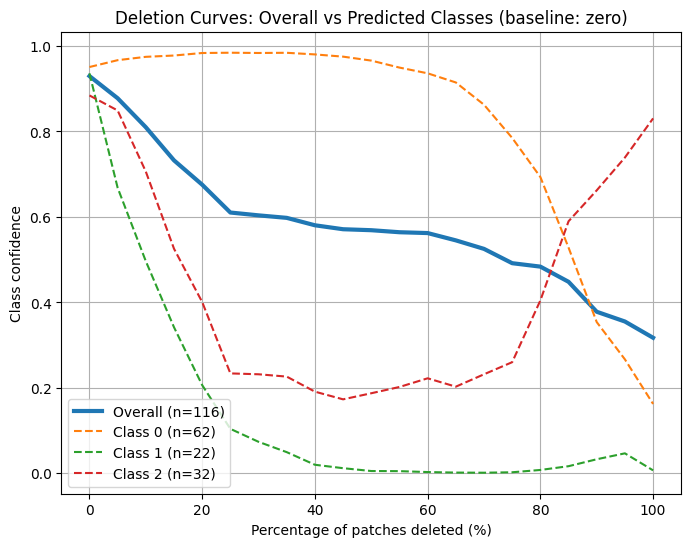

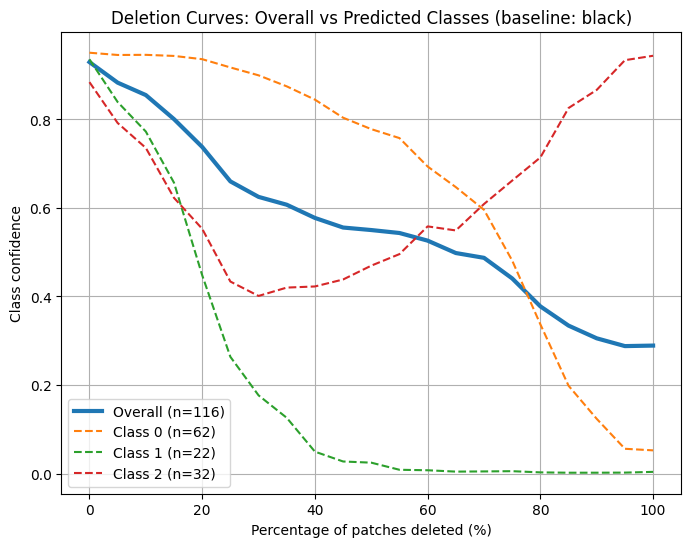

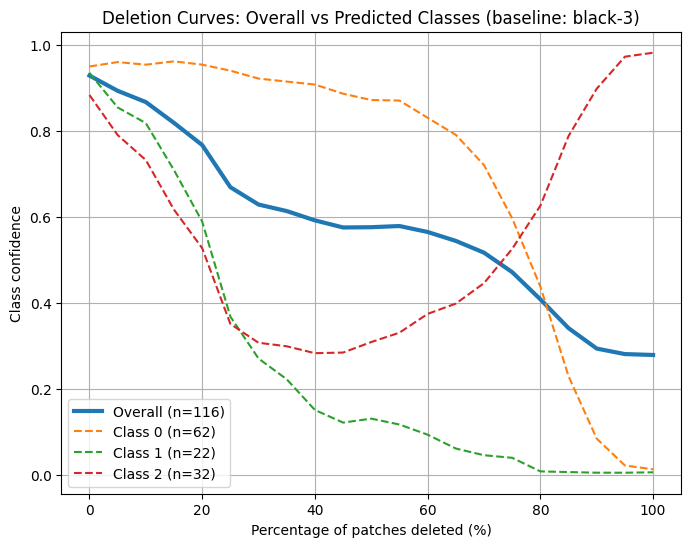

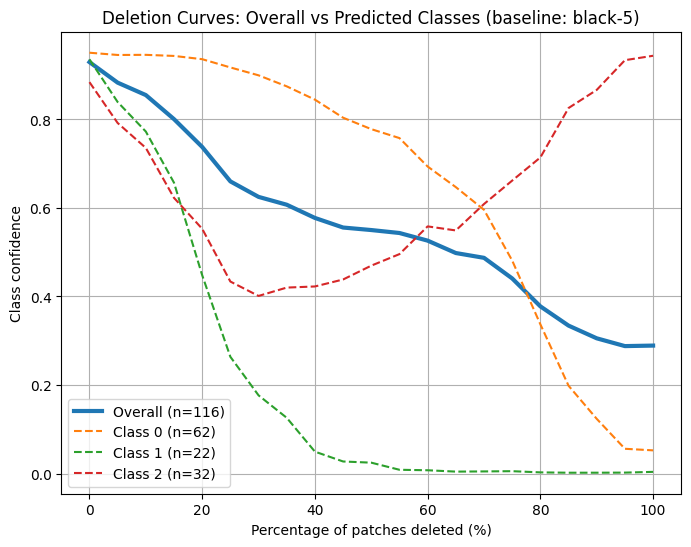

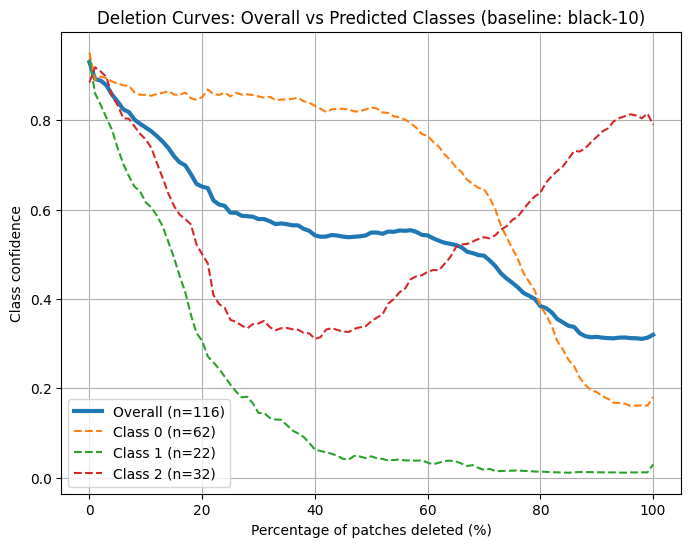

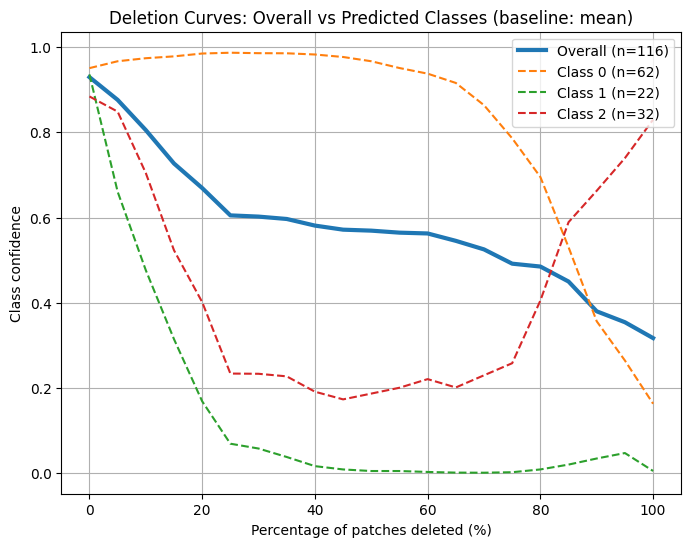

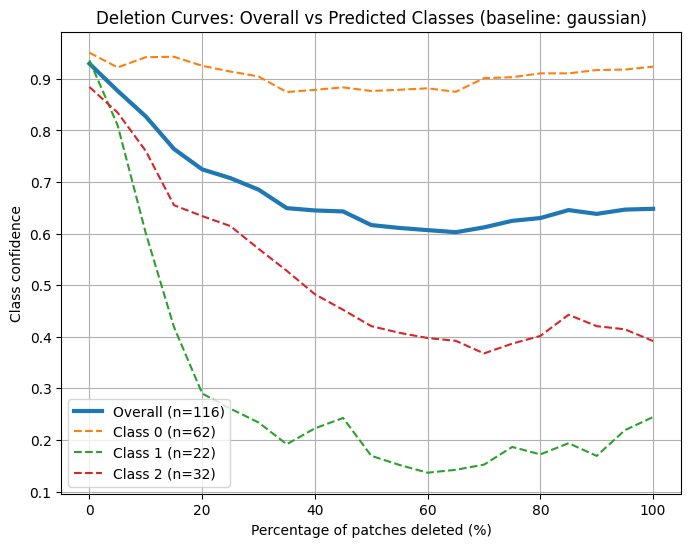

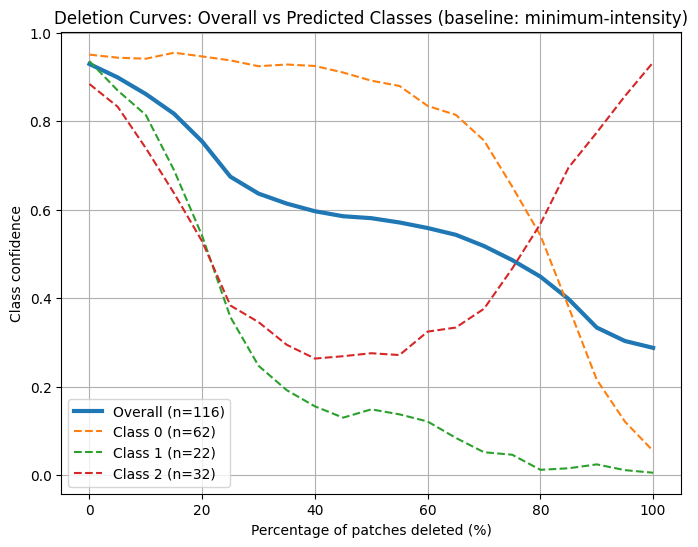

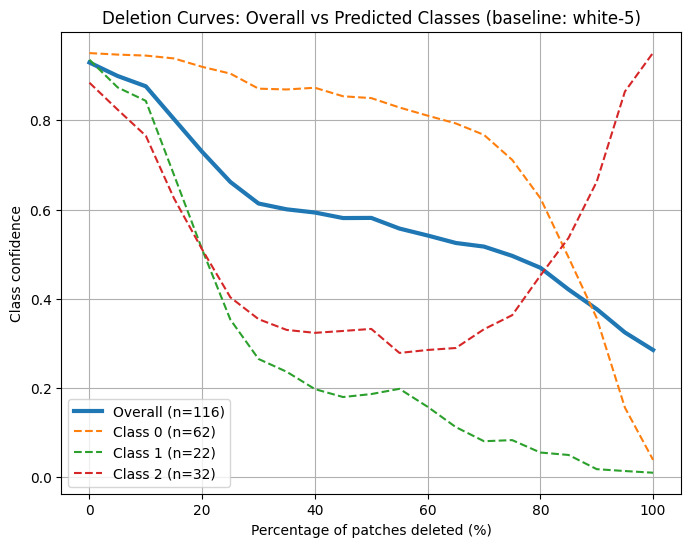

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path(
    "/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/"
    "evaluation_results/deletion"
)

BASELINES = {
    "attention_mask": "attention_mask",
    "zero": "zero",
    "black": "black",
    "black-3": "black-3",
    "black-5": "black-5",
    "black-10": "black-10",
    "mean": "mean",
    "gaussian": "gaussian",
    "minimum-intensity": "minimum-intensity",
    "white-5": "white-5",

}

for baseline in BASELINES.values():
    curve_dir = BASE_DIR / "deletion_curves" / "attention_rollout" / baseline
    csv_path = BASE_DIR /  f"deletion_attention_rollout_{baseline}.csv"

    # Load CSV
    df = pd.read_csv(csv_path)
    uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

    all_curves = []
    class_curves = {}
    percentages = None

    # Load curves
    for f in curve_dir.glob("*.npy"):
        if baseline == "zero":
            uid = f.stem.replace("_curve", "")
        else:
            uid = f.stem.replace(f"_curve_{baseline}", "")
        
        if uid not in uid_to_class:
            continue

        data = np.load(f, allow_pickle=True).item()
        confidences = data["predicted_confidences"]
        
        all_curves.append(confidences)
        
        cls = uid_to_class[uid]
        if cls not in class_curves:
            class_curves[cls] = []
        class_curves[cls].append(confidences)
        
        if percentages is None:
            percentages = data["percentages"]

    # Safety check
    if len(all_curves) == 0:
        print(f"Warning: No matching curves found for baseline '{baseline}'. Skipping.")
        raise ValueError(f"No matching curves found for baseline '{baseline}'.")

    # Convert to numpy
    all_curves = np.array(all_curves)
    overall_mean = all_curves.mean(axis=0)

    # Plot
    x_percent = np.array(percentages) * 100
    plt.figure(figsize=(8, 6))

    # Overall curve (thicker line)
    plt.plot(
        x_percent,
        overall_mean,
        linewidth=3,
        label=f"Overall (n={len(all_curves)})"
    )

    # Per-class curves
    for cls, curves in sorted(class_curves.items()):
        curves = np.array(curves)
        mean_curve = curves.mean(axis=0)
        plt.plot(
            x_percent,
            mean_curve,
            linestyle="--",
            label=f"Class {cls} (n={len(curves)})"
        )

    plt.xlabel("Percentage of patches deleted (%)")
    plt.ylabel("Class confidence")
    plt.title("Deletion Curves: Overall vs Predicted Classes (baseline: {})".format(baseline))
    plt.legend()
    plt.grid(True)
    plt.show()
